In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from pathlib import Path
from collections import Counter

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

# Robust path: work whether run from repo root or notebooks folder
candidate_paths = [
    Path.cwd() / 'data' / 'raw',
    Path.cwd().parent / 'data' / 'raw'
]
raw_dir = next((p for p in candidate_paths if p.exists()), None)
if raw_dir is None:
    raise FileNotFoundError("Khong tim thay thu muc data/raw. Hay kiem tra lai duong dan du lieu.")

df_recipes = pd.read_csv(raw_dir / 'RAW_recipes.csv')
df_interactions = pd.read_csv(raw_dir / 'RAW_interactions.csv')

print(f"Recipes: {df_recipes.shape[0]} dòng x {df_recipes.shape[1]} cột")
print(f"Interactions: {df_interactions.shape[0]} dòng x {df_interactions.shape[1]} cột")

Recipes: 231637 dòng x 12 cột
Interactions: 1132367 dòng x 5 cột


In [20]:
display(df_recipes.columns)
display(df_interactions.columns)

display(df_recipes.head(1))                                # Hiển thị món
display(df_interactions.head(1))                           # Hiển thị review

# Kiểu DL từng cột
df_recipes.dtypes
df_interactions.dtypes

# Kiểm tra các kiểu dữ liệu
df_recipes.info()
df_interactions.info()

#Thống kê dữ liệu
df_recipes.describe()
df_interactions.describe()

Index(['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
       'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients'],
      dtype='str')

Index(['user_id', 'recipe_id', 'date', 'rating', 'review'], dtype='str')

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course', 'main-i...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'depending on ...",autumn is my favorite time of year to cook! this recipe ...,"['winter squash', 'mexican seasoning', 'mixed spice', 'h...",7


,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for 15 minute...


<class 'pandas.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   name            231636 non-null  str  
 1   id              231637 non-null  int64
 2   minutes         231637 non-null  int64
 3   contributor_id  231637 non-null  int64
 4   submitted       231637 non-null  str  
 5   tags            231637 non-null  str  
 6   nutrition       231637 non-null  str  
 7   n_steps         231637 non-null  int64
 8   steps           231637 non-null  str  
 9   description     226658 non-null  str  
 10  ingredients     231637 non-null  str  
 11  n_ingredients   231637 non-null  int64
dtypes: int64(5), str(7)
memory usage: 21.2 MB
<class 'pandas.DataFrame'>
RangeIndex: 1132367 entries, 0 to 1132366
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1132367 non-null  int64
 1   recipe_id  

,user_id,recipe_id,rating
count,1132367.00,1132367.00,1132367.00
mean,138429067.43,160897.21,4.41
std,501426863.68,130398.72,1.26
min,1533.00,38.00,0.00
25%,135470.00,54257.00,4.00
50%,330937.00,120547.00,5.00
75%,804550.00,243852.00,5.00
max,2002372706.00,537716.00,5.00


In [ ]:
# Kiểm tra dữ liệu bị null
df_recipes.isnull().sum()

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

In [ ]:
# Kiểm tra dữ liệu trùng
df_recipes.duplicated().sum()                           

np.int64(0)

In [ ]:
#Đếm số nguyên liệu mỗi món
df_recipes['num_ingredients'] = df_recipes['ingredients'].apply(len)        
df_recipes['ingredient_list'] = df_recipes['ingredients'].apply(lambda x: x.split(','))


print(df_recipes['num_ingredients'])

0          93
1          86
2         193
3         186
4         110
         ... 
231632    345
231633    205
231634    146
231635    162
231636    104
Name: num_ingredients, Length: 231637, dtype: int64


In [ ]:
from collections import Counter

all_ingredients = []

for i in df_recipes['ingredient_list']:
    all_ingredients.extend(i)

# Tìm nguyên liệu phổ biến nhất
Counter(all_ingredients).most_common(10)                    

[(" 'salt'", 78127),
 (" 'butter'", 38862),
 (" 'sugar'", 38756),
 (" 'onion'", 35739),
 (" 'eggs'", 28726),
 (" 'water'", 27119),
 (" 'garlic cloves'", 24459),
 (" 'olive oil'", 23934),
 (" 'milk'", 21359),
 (" 'flour'", 19695)]

In [ ]:
nutrition_cols = [
    "calories",
    "fat",
    "sugar",
    "sodium",
    "protein",
    "saturated_fat",
    "carbs"
]

df_recipes[nutrition_cols] = pd.DataFrame(
    df_recipes['nutrition'].apply(ast.literal_eval).tolist(),
    index=df_recipes.index
)

df_recipes[nutrition_cols].describe()


,calories,fat,sugar,sodium,protein,saturated_fat,carbs
count,231637.00,231637.00,231637.00,231637.00,231637.00,231637.00,231637.00
mean,473.94,36.08,84.30,30.15,34.68,45.59,15.56
std,1189.71,77.80,800.08,131.96,58.47,98.24,81.82
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,174.40,8.00,9.00,5.00,7.00,7.00,4.00
50%,313.40,20.00,25.00,14.00,18.00,23.00,9.00
75%,519.70,41.00,68.00,33.00,51.00,52.00,16.00
max,434360.20,17183.00,362729.00,29338.00,6552.00,10395.00,36098.00


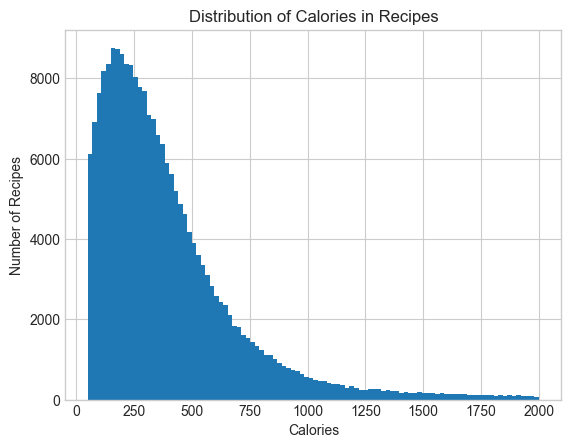

In [ ]:
plt.Figure(figsize=(8,5))

# Kiểm tra recipes có calo dưới 2000 ta thấy hầu hết recipes đều chứa từ 200-400 calories, cho thấy dataset chủ yếu bao gồm các món ăn thông thường
df_recipes_hist_calo = df_recipes[df_recipes['calories'] < 2000]
df_recipes_hist_calo['calories'].hist(bins=100,range=(50,2000))

plt.title("Distribution of Calories in Recipes")
plt.xlabel("Calories")
plt.ylabel("Number of Recipes")
plt.show()

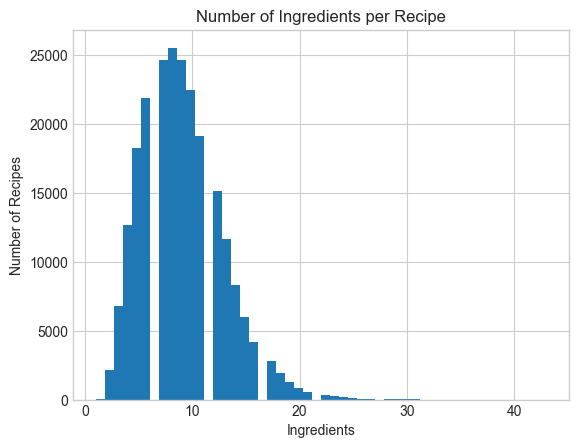

In [ ]:
plt.Figure(figsize=(8,5))

# Kiểm tra recipes có Ingredients đều chứa nguyên liệu từ 6-10, ta thấy được các nguyên liệu điển hình cho các công thức nấu ăn tại nhà
df_recipes['n_ingredients'].hist(bins=50)
df_recipes['n_ingredients'].describe

plt.title("Number of Ingredients per Recipe")
plt.xlabel("Ingredients")
plt.ylabel("Number of Recipes")
plt.show()

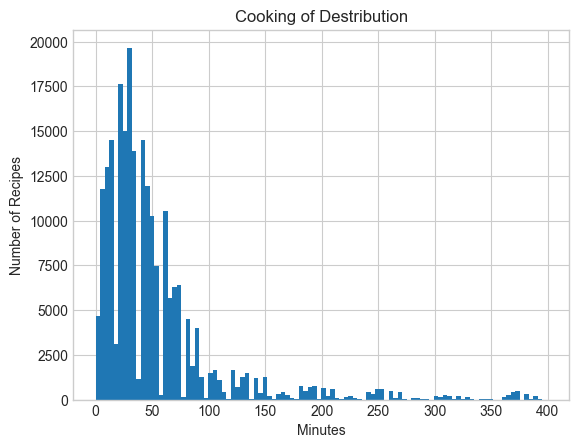

In [ ]:
plt.Figure(figsize=(8,5))

# Kiểm tra recipes có Minutes đều có thời gian nấu từ 20-30 phút, ta thấy được thời gian nấu rất hợp trong nấu ăn gia đình
df_recipes_hist_minutes = df_recipes[df_recipes['minutes'] < 400]
df_recipes_hist_minutes['minutes'].hist(bins=100)
df_recipes_hist_minutes['minutes'].describe

plt.title("Cooking Time Destribution")
plt.xlabel("Minutes")
plt.ylabel("Number of Recipes")
plt.show()

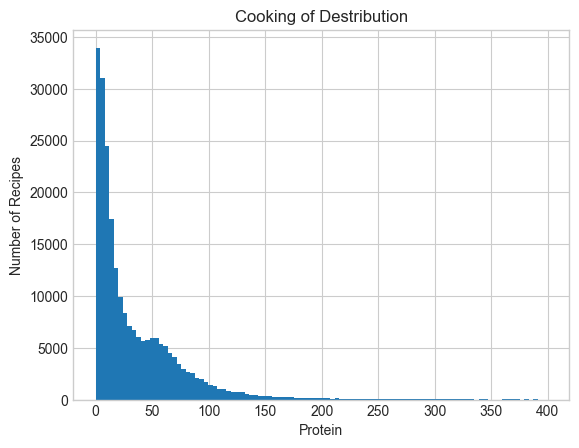

In [ ]:
plt.Figure(figsize=(8,5))

# Kiểm tra recipes có Protein đều từ 10-30, ta thấy được lượng protein vừa đủ cho 1 món ăn
df_recipes_hist_protein = df_recipes[df_recipes['protein'] < 400]
df_recipes_hist_protein['protein'].hist(bins=100)
df_recipes_hist_protein['protein'].describe

plt.title("Protein Destribution")
plt.xlabel("Protein")
plt.ylabel("Number of Recipes")
plt.show()

In [ ]:
# Convert string cho ingredients và tags
def parse_list(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

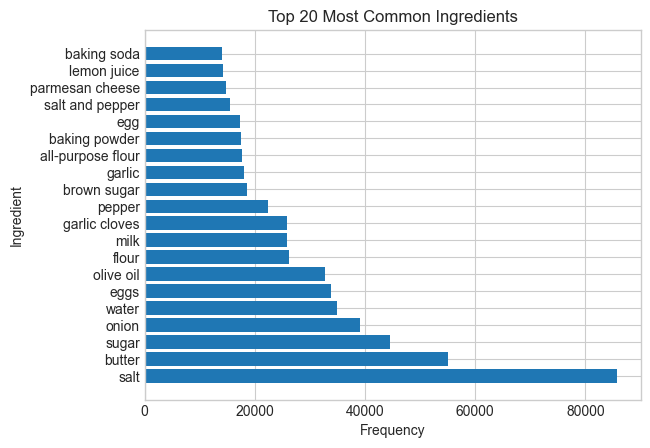

In [ ]:
# TOP INGREDIENTS
df_recipes['ingredients'] = df_recipes['ingredients'].apply(parse_list)

all_ingredients_detail = []

for ingredients in df_recipes['ingredients']:
    all_ingredients_detail.extend(ingredients)

ingredients_counts = Counter(all_ingredients_detail)
top_ingredients = ingredients_counts.most_common(20)

ingredients, counts = zip(*top_ingredients)

plt.Figure(figsize=(10,6))
plt.barh(ingredients, counts)
plt.title("Top 20 Most Common Ingredients")
plt.xlabel("Frequency")
plt.ylabel("Ingredient")
plt.show()

In [ ]:
display(top_ingredients)

[('salt', 85746),
 ('butter', 54975),
 ('sugar', 44535),
 ('onion', 39065),
 ('water', 34914),
 ('eggs', 33761),
 ('olive oil', 32822),
 ('flour', 26266),
 ('milk', 25786),
 ('garlic cloves', 25748),
 ('pepper', 22319),
 ('brown sugar', 18655),
 ('garlic', 18087),
 ('all-purpose flour', 17659),
 ('baking powder', 17504),
 ('egg', 17304),
 ('salt and pepper', 15415),
 ('parmesan cheese', 14807),
 ('lemon juice', 14233),
 ('baking soda', 14099)]

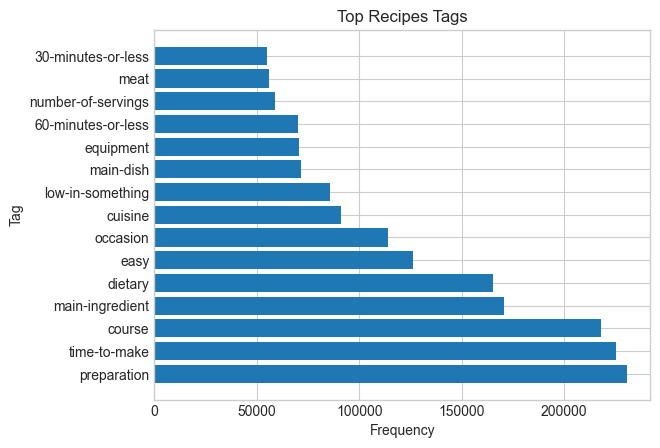

In [ ]:
# TAG DISTRIBUTION
df_recipes['tags'] = df_recipes['tags'].apply(parse_list)

all_tags = []

for tags in df_recipes['tags']:
    all_tags.extend(tags)

tag_counts = Counter(all_tags)
top_tags = tag_counts.most_common(15)

tags, counts = zip(*top_tags)

plt.Figure(figsize=(10,6))
plt.barh(tags, counts)

plt.title("Top Recipes Tags")
plt.xlabel("Frequency")
plt.ylabel("Tag")
plt.show()